Dataset Shape: (768, 7)

First 5 Rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Columns:
Index(['Region', ' Date', ' Freq

/tmp/ipykernel_20971/683829763.py:30: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


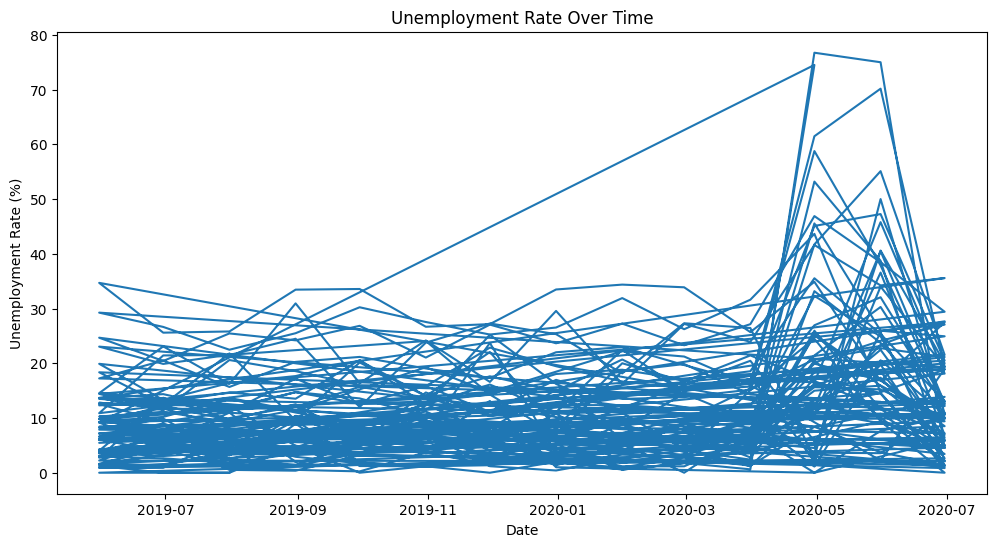

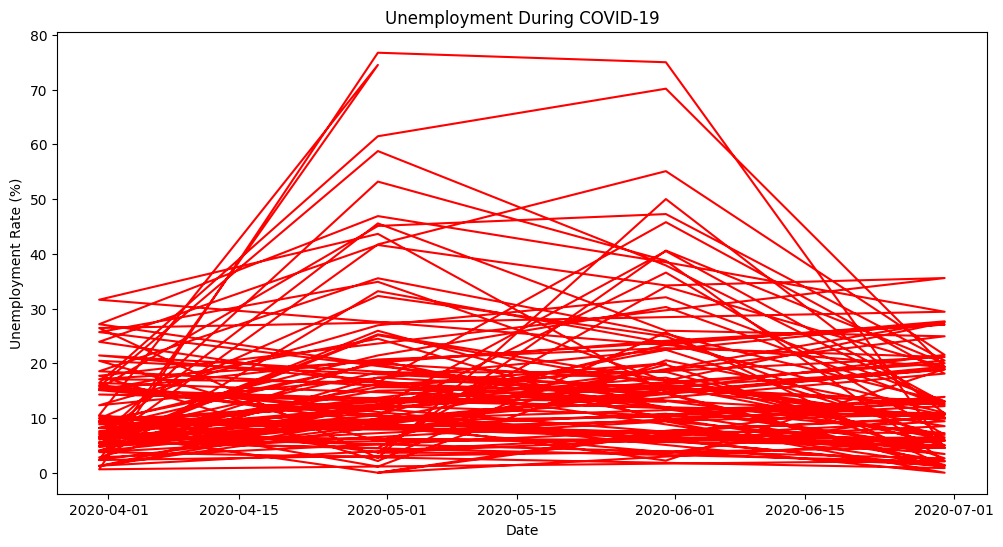

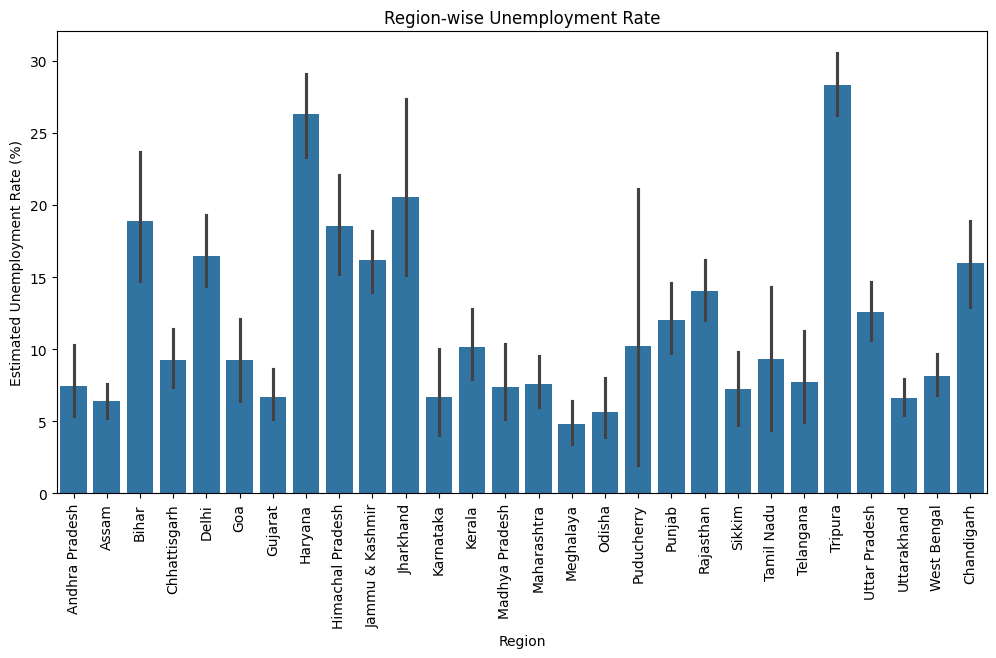


Average Unemployment Rate:
11.787945945945946


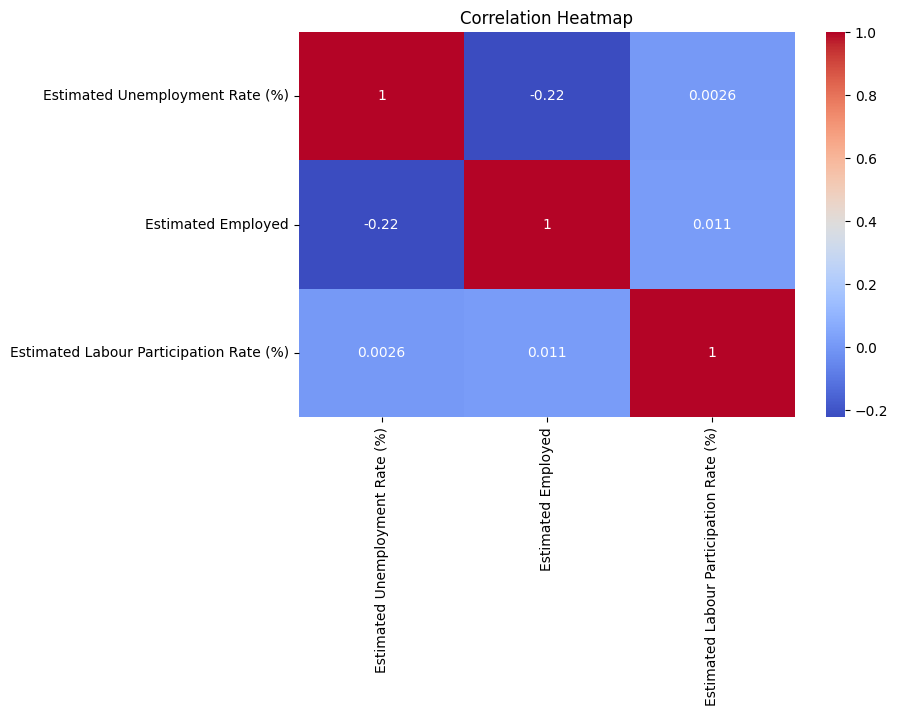


Key Insights:
- Unemployment varies across time and regions
- COVID period shows spike in unemployment
- Data helps in economic decision making


In [2]:
# =========================
# TASK 2 - UNEMPLOYMENT ANALYSIS
# =========================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD DATASET (UPLOAD CSV FIRST)
df = pd.read_csv("/content/Unemployment in India.csv")

# 3. BASIC INFO
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

# 4. CLEAN COLUMN NAMES
df.columns = df.columns.str.strip()

# 5. CONVERT DATE COLUMN (if exists)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

# =========================
# 6. OVERALL TREND ANALYSIS
# =========================
if 'Date' in df.columns and 'Estimated Unemployment Rate (%)' in df.columns:
    plt.figure(figsize=(12,6))
    plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
    plt.title("Unemployment Rate Over Time")
    plt.xlabel("Date")
    plt.ylabel("Unemployment Rate (%)")
    plt.show()

# =========================
# 7. COVID IMPACT ANALYSIS
# =========================
if 'Date' in df.columns:
    covid_df = df[df['Date'] >= '2020-03-01']

    if 'Estimated Unemployment Rate (%)' in df.columns:
        plt.figure(figsize=(12,6))
        plt.plot(covid_df['Date'], covid_df['Estimated Unemployment Rate (%)'], color='red')
        plt.title("Unemployment During COVID-19")
        plt.xlabel("Date")
        plt.ylabel("Unemployment Rate (%)")
        plt.show()

# =========================
# 8. REGION / STATE ANALYSIS
# =========================
if 'Region' in df.columns and 'Estimated Unemployment Rate (%)' in df.columns:
    plt.figure(figsize=(12,6))
    sns.barplot(
        x='Region',
        y='Estimated Unemployment Rate (%)',
        data=df
    )
    plt.xticks(rotation=90)
    plt.title("Region-wise Unemployment Rate")
    plt.show()

# =========================
# 9. AVERAGE UNEMPLOYMENT
# =========================
if 'Estimated Unemployment Rate (%)' in df.columns:
    print("\nAverage Unemployment Rate:")
    print(df['Estimated Unemployment Rate (%)'].mean())

# =========================
# 10. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 11. INSIGHTS
# =========================
print("\nKey Insights:")
print("- Unemployment varies across time and regions")
print("- COVID period shows spike in unemployment")
print("- Data helps in economic decision making")